# Marathon Race Time Predictor — XGBoost Model
This notebook trains an XGBoost model on marathon runner data.
Run each cell top to bottom.

## Step 1 — Install packages

In [ ]:
pip install xgboost scikit-learn pandas numpy matplotlib seaborn

## Step 2 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import math
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

print('All libraries imported successfully')

All libraries imported successfully


## Step 3 — Load data

In [2]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (80000, 41)
Test shape:  (20000, 40)


,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


## Step 4 — Explore the data

In [3]:
# Check null values
print('Null counts:')
print(train_df.isnull().sum())

Null counts:
runner_id                             0
age                                   0
gender                                0
running_experience_months             0
previous_marathon_count               0
training_program                      0
motivation_level                      0
personal_best_minutes             10745
weekly_mileage_km                     0
weekly_mileage_miles                  0
runs_per_week                         0
long_run_distance_km                  0
speed_work_sessions_per_week          0
rest_days_per_week                    0
training_adherence_pct                0
consecutive_weeks_no_miss             0
cross_training_hours_per_week      7983
resting_heart_rate_bpm                0
vo2_max                            9611
bmi                                   0
recovery_score                        0
sleep_hours_avg                    3942
injury_count                          0
injury_severity                   47350
nutrition_score            

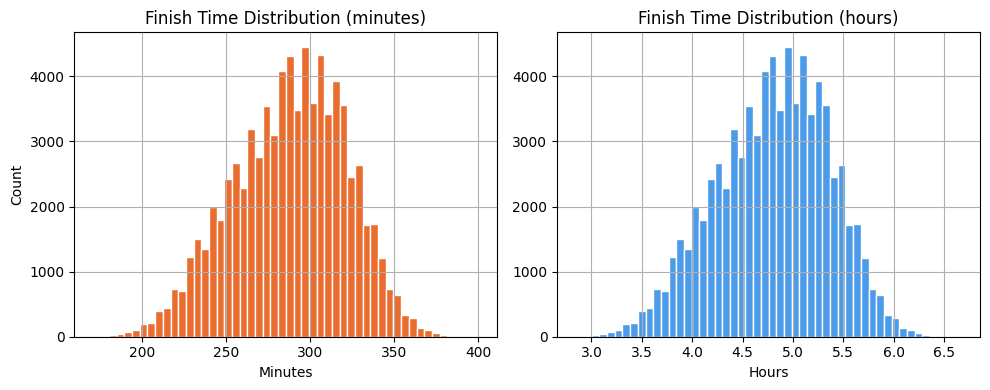


Target stats (minutes):
count    78011.000000
mean       287.931407
std         33.648005
min        171.000000
25%        265.000000
50%        290.000000
75%        313.000000
max        400.000000
Name: actual_finish_time_minutes, dtype: float64


In [4]:
# Target variable distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
train_df['actual_finish_time_minutes'].dropna().hist(bins=50, color='#e86d2e', edgecolor='white')
plt.title('Finish Time Distribution (minutes)')
plt.xlabel('Minutes')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
# Convert to hours:minutes for readability
hours = train_df['actual_finish_time_minutes'].dropna() / 60
hours.hist(bins=50, color='#4c9be8', edgecolor='white')
plt.title('Finish Time Distribution (hours)')
plt.xlabel('Hours')
plt.tight_layout()
plt.show()

print('\nTarget stats (minutes):')
print(train_df['actual_finish_time_minutes'].describe())

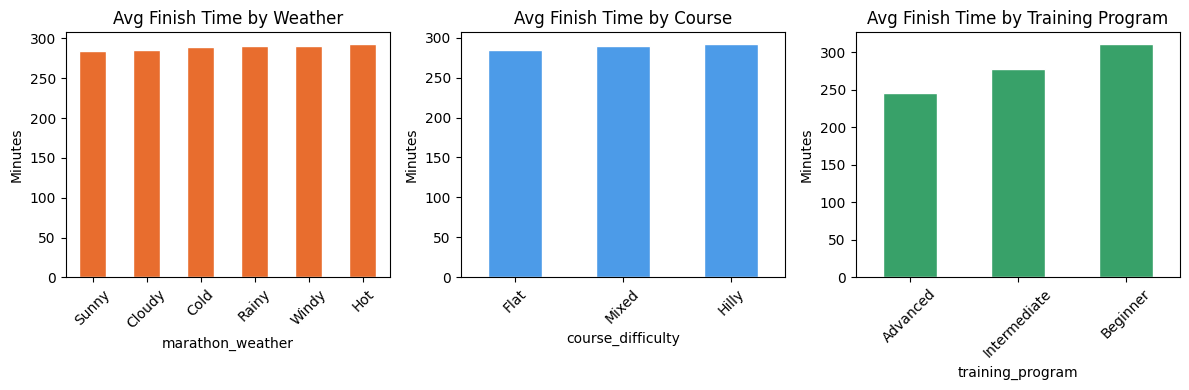

In [5]:
# Weather impact on finish time
clean = train_df.dropna(subset=['actual_finish_time_minutes'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
weather_avg = clean.groupby('marathon_weather')['actual_finish_time_minutes'].mean().sort_values()
weather_avg.plot(kind='bar', color='#e86d2e', edgecolor='white')
plt.title('Avg Finish Time by Weather')
plt.ylabel('Minutes')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
course_avg = clean.groupby('course_difficulty')['actual_finish_time_minutes'].mean().sort_values()
course_avg.plot(kind='bar', color='#4c9be8', edgecolor='white')
plt.title('Avg Finish Time by Course')
plt.ylabel('Minutes')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
program_avg = clean.groupby('training_program')['actual_finish_time_minutes'].mean().sort_values()
program_avg.plot(kind='bar', color='#38a169', edgecolor='white')
plt.title('Avg Finish Time by Training Program')
plt.ylabel('Minutes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

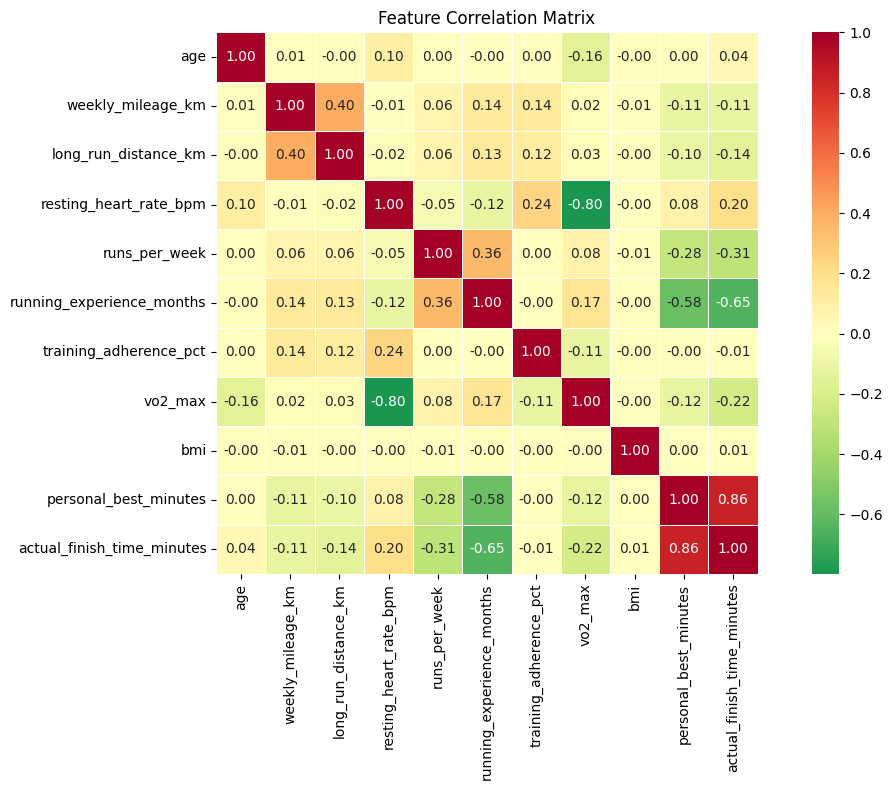

In [6]:
# Correlation heatmap of numeric features
numeric_cols = [
    'age', 'weekly_mileage_km', 'long_run_distance_km',
    'resting_heart_rate_bpm', 'runs_per_week',
    'running_experience_months', 'training_adherence_pct',
    'vo2_max', 'bmi', 'personal_best_minutes',
    'actual_finish_time_minutes'
]
corr = clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 5 — Feature Engineering

In [7]:
# Drop rows where target is missing
train_df = train_df.dropna(subset=['actual_finish_time_minutes'])
print(f'Training rows after cleaning: {len(train_df)}')

# Fill VO2 max using resting HR + age formula
# VO2max ≈ 15 × (HRmax / HRrest), HRmax ≈ 220 - age
def estimate_vo2(row):
    if not pd.isna(row['vo2_max']):
        return row['vo2_max']
    return 15 * ((220 - row['age']) / row['resting_heart_rate_bpm'])

train_df['vo2_max'] = train_df.apply(estimate_vo2, axis=1)
test_df['vo2_max']  = test_df.apply(estimate_vo2, axis=1)

# Fill personal_best_minutes with median per training_program
pb_medians = train_df.groupby('training_program')['personal_best_minutes'].median()
print('Personal best medians by program:')
print(pb_medians)

def fill_pb(row, medians):
    if not pd.isna(row['personal_best_minutes']):
        return row['personal_best_minutes']
    return medians.get(row['training_program'], medians.mean())

train_df['personal_best_minutes'] = train_df.apply(lambda r: fill_pb(r, pb_medians), axis=1)
test_df['personal_best_minutes']  = test_df.apply(lambda r: fill_pb(r, pb_medians), axis=1)

print('\nRemaining nulls in key features:')
key_features = ['weekly_mileage_km', 'long_run_distance_km', 'resting_heart_rate_bpm',
                'vo2_max', 'personal_best_minutes', 'running_experience_months']
print(train_df[key_features].isnull().sum())

Training rows after cleaning: 78011
Personal best medians by program:
training_program
Advanced        220.0
Beginner        280.0
Intermediate    250.0
Name: personal_best_minutes, dtype: float64

Remaining nulls in key features:
weekly_mileage_km            0
long_run_distance_km         0
resting_heart_rate_bpm       0
vo2_max                      0
personal_best_minutes        0
running_experience_months    0
dtype: int64


## Step 6 — Encode Categorical Features

In [8]:
label_encoders = {}
categorical_cols = ['marathon_weather', 'course_difficulty', 'gender', 'training_program']

for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nEncoding complete')

marathon_weather: {'Cloudy': np.int64(0), 'Cold': np.int64(1), 'Hot': np.int64(2), 'Rainy': np.int64(3), 'Sunny': np.int64(4), 'Windy': np.int64(5)}
course_difficulty: {'Flat': np.int64(0), 'Hilly': np.int64(1), 'Mixed': np.int64(2)}
gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Non-binary': np.int64(2)}
training_program: {'Advanced': np.int64(0), 'Beginner': np.int64(1), 'Intermediate': np.int64(2)}

Encoding complete


## Step 7 — Prepare Features and Target

In [9]:
FEATURES = [
    'weekly_mileage_km',
    'runs_per_week',
    'long_run_distance_km',
    'speed_work_sessions_per_week',
    'training_adherence_pct',
    'running_experience_months',
    'resting_heart_rate_bpm',
    'vo2_max',
    'previous_marathon_count',
    'personal_best_minutes',
    'marathon_weather',
    'course_difficulty',
    'age',
    'gender',
    'training_program',
]

TARGET = 'actual_finish_time_minutes'

X = train_df[FEATURES]
y = train_df[TARGET]

X_test_final = test_df[FEATURES]
y_test_final = test_df[TARGET] if TARGET in test_df.columns else None

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test_final.shape}')
print(f'Features: {FEATURES}')

X_train: (70209, 15)
X_val:   (7802, 15)
X_test:  (20000, 15)
Features: ['weekly_mileage_km', 'runs_per_week', 'long_run_distance_km', 'speed_work_sessions_per_week', 'training_adherence_pct', 'running_experience_months', 'resting_heart_rate_bpm', 'vo2_max', 'previous_marathon_count', 'personal_best_minutes', 'marathon_weather', 'course_difficulty', 'age', 'gender', 'training_program']


## Step 8 — Train XGBoost Model

In [10]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mae'
)

print('Training XGBoost...')
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)
print('Training complete!')

Training XGBoost...
[0]	validation_0-mae:26.33333
[100]	validation_0-mae:12.00153
[200]	validation_0-mae:11.95801
[223]	validation_0-mae:11.96191
Training complete!


## Step 9 — Evaluate the Model

In [11]:
# Validation metrics
val_pred = model.predict(X_val)
val_mae  = mean_absolute_error(y_val, val_pred)
val_r2   = r2_score(y_val, val_pred)

print(f'Validation MAE: {val_mae:.2f} minutes ({val_mae/60:.2f} hours)')
print(f'Validation R2:  {val_r2:.4f}')

if y_test_final is not None:
    test_clean = test_df.dropna(subset=[TARGET])
    test_pred  = model.predict(test_clean[FEATURES])
    test_mae   = mean_absolute_error(test_clean[TARGET], test_pred)
    test_r2    = r2_score(test_clean[TARGET], test_pred)
    print(f'\nTest MAE: {test_mae:.2f} minutes ({test_mae/60:.2f} hours)')
    print(f'Test R2:  {test_r2:.4f}')

Validation MAE: 11.96 minutes (0.20 hours)
Validation R2:  0.7944

Test MAE: 11.92 minutes (0.20 hours)
Test R2:  0.7945


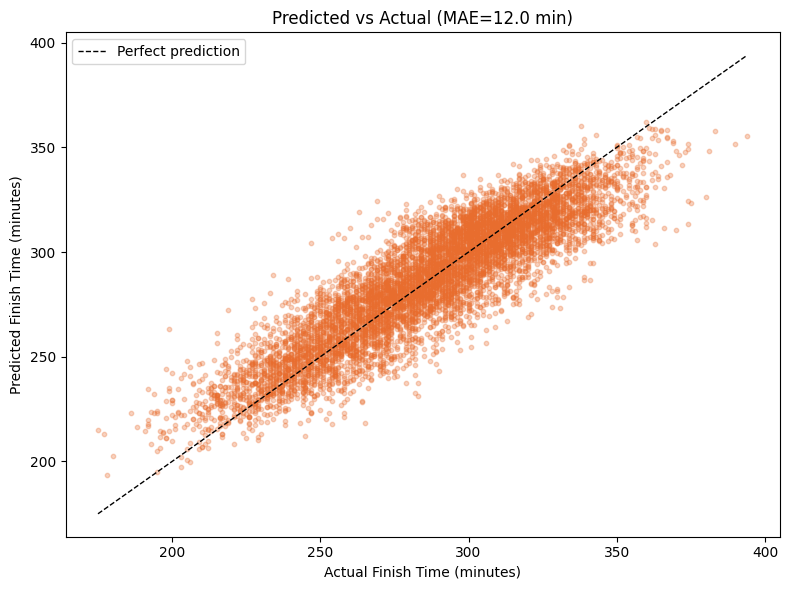

In [12]:
# Predicted vs Actual scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_val, val_pred, alpha=0.3, color='#e86d2e', s=10)
min_val = min(y_val.min(), val_pred.min())
max_val = max(y_val.max(), val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='Perfect prediction')
plt.xlabel('Actual Finish Time (minutes)')
plt.ylabel('Predicted Finish Time (minutes)')
plt.title(f'Predicted vs Actual (MAE={val_mae:.1f} min)')
plt.legend()
plt.tight_layout()
plt.show()

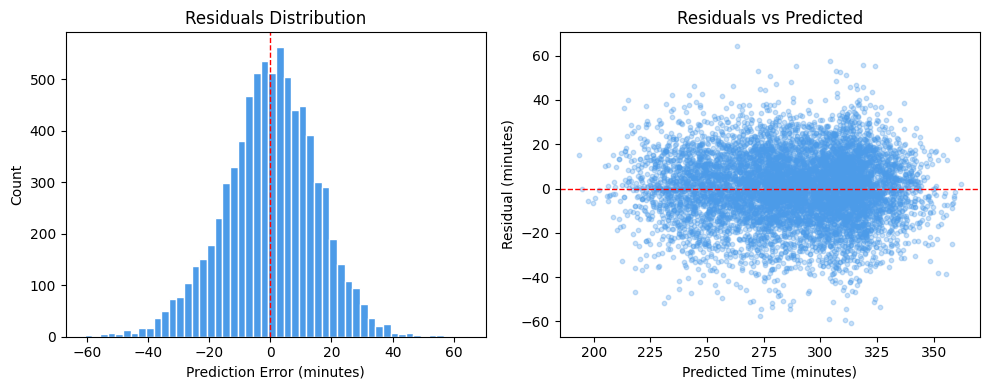

In [13]:
# Residuals distribution
residuals = val_pred - y_val
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, color='#4c9be8', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', lw=1)
plt.xlabel('Prediction Error (minutes)')
plt.ylabel('Count')
plt.title('Residuals Distribution')

plt.subplot(1, 2, 2)
plt.scatter(val_pred, residuals, alpha=0.3, color='#4c9be8', s=10)
plt.axhline(0, color='red', linestyle='--', lw=1)
plt.xlabel('Predicted Time (minutes)')
plt.ylabel('Residual (minutes)')
plt.title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

## Step 10 — Feature Importance

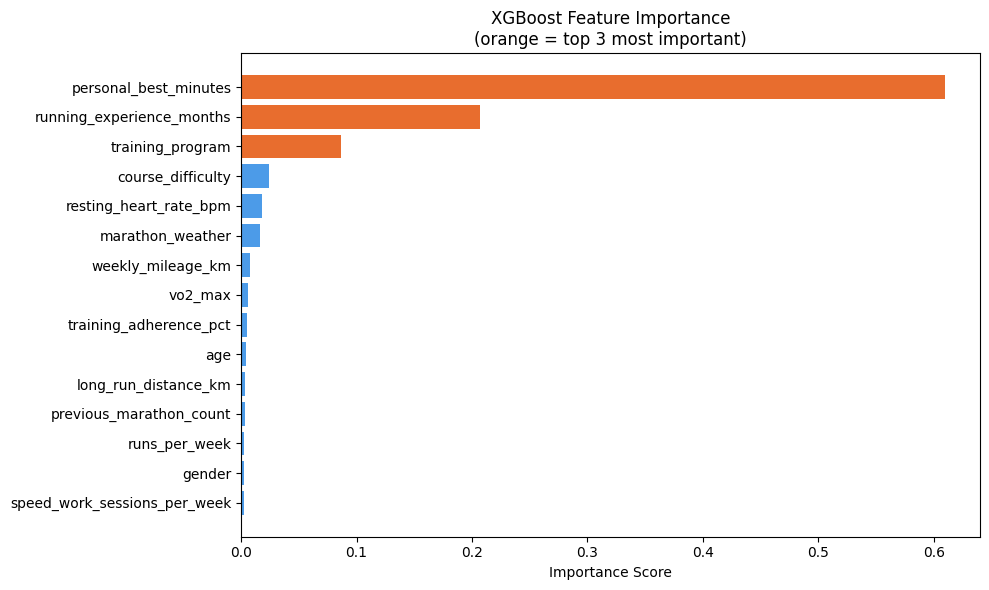


Feature importances:
  personal_best_minutes               0.610  ████████████████████████████████████████████████████████████
  running_experience_months           0.207  ████████████████████
  training_program                    0.086  ████████
  course_difficulty                   0.024  ██
  resting_heart_rate_bpm              0.018  █
  marathon_weather                    0.016  █
  weekly_mileage_km                   0.008  
  vo2_max                             0.006  
  training_adherence_pct              0.005  
  age                                 0.005  
  long_run_distance_km                0.004  
  previous_marathon_count             0.003  
  runs_per_week                       0.003  
  gender                              0.003  
  speed_work_sessions_per_week        0.003  


In [14]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e86d2e' if i >= len(FEATURES) - 3 else '#4c9be8'
          for i in range(len(FEATURES))]
plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance\n(orange = top 3 most important)')
plt.tight_layout()
plt.show()

print('\nFeature importances:')
for _, row in feat_imp.sort_values('importance', ascending=False).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"  {row['feature']:<35} {row['importance']:.3f}  {bar}")

## Step 11 — Weather Penalty Validation
Verify the weather penalty curves match real-world data (Mumbai vs Delhi example)

In [15]:
def calculate_heat_index(temp_c, humidity_pct):
    if temp_c < 10:
        return temp_c
    hi = (temp_c +
          (0.33 * (humidity_pct / 100) *
           6.105 * math.exp(17.27 * temp_c / (237.7 + temp_c))) - 4.0)
    return hi

def weather_penalty_multiplier(temp_c, humidity_pct):
    heat_index = calculate_heat_index(temp_c, humidity_pct)
    if heat_index <= 10:
        penalty = 1.0 + max(0, (10 - heat_index)) * 0.002
    elif heat_index <= 15:
        penalty = 1.0
    elif heat_index <= 20:
        penalty = 1.0 + (heat_index - 15) * 0.004
    elif heat_index <= 25:
        penalty = 1.02 + (heat_index - 20) * 0.006
    elif heat_index <= 30:
        penalty = 1.05 + (heat_index - 25) * 0.008
    elif heat_index <= 35:
        penalty = 1.09 + (heat_index - 30) * 0.010
    else:
        penalty = 1.14 + (heat_index - 35) * 0.012
    return round(penalty, 4)

# Your real races
races = [
    {'name': 'Delhi Half Marathon', 'temp': 15, 'humidity': 30, 'actual': 106},   # 1:46
    {'name': 'Mumbai TMM Half',     'temp': 28, 'humidity': 83, 'actual': 116},   # 1:56
]

base_time = 110  # your baseline fitness (~1:50 half marathon)

print('Weather penalty validation:')
print(f'{"Race":<25} {"Temp":>6} {"Humidity":>9} {"HeatIdx":>8} {"Penalty":>8} {"Predicted":>10} {"Actual":>8}')
print('-' * 80)
for r in races:
    hi      = calculate_heat_index(r['temp'], r['humidity'])
    penalty = weather_penalty_multiplier(r['temp'], r['humidity'])
    pred    = base_time * penalty
    pred_h  = int(pred // 60)
    pred_m  = int(pred % 60)
    act_h   = int(r['actual'] // 60)
    act_m   = int(r['actual'] % 60)
    print(f"{r['name']:<25} {r['temp']:>5}°C {r['humidity']:>8}% {hi:>8.1f} {penalty:>8.3f} "
          f"{pred_h}:{pred_m:02d}:00  {act_h}:{act_m:02d}:00")

Weather penalty validation:
Race                        Temp  Humidity  HeatIdx  Penalty  Predicted   Actual
--------------------------------------------------------------------------------
Delhi Half Marathon          15°C       30%     12.7    1.000 1:50:00  1:46:00
Mumbai TMM Half              28°C       83%     34.3    1.133 2:04:00  1:56:00


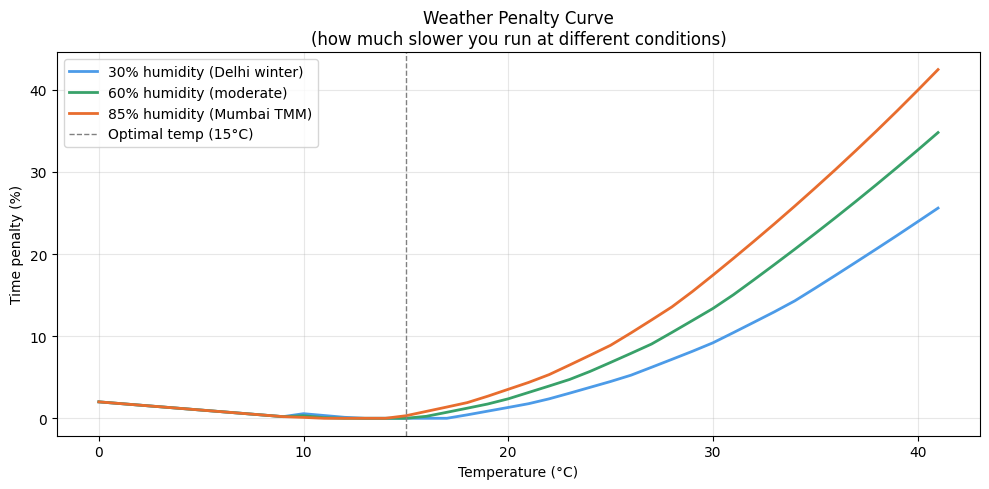

In [16]:
# Plot weather penalty curve
temps     = range(0, 42)
humid_low  = [weather_penalty_multiplier(t, 30) for t in temps]   # Delhi-like
humid_mid  = [weather_penalty_multiplier(t, 60) for t in temps]   # Moderate
humid_high = [weather_penalty_multiplier(t, 85) for t in temps]   # Mumbai-like

plt.figure(figsize=(10, 5))
plt.plot(temps, [(p-1)*100 for p in humid_low],  label='30% humidity (Delhi winter)', color='#4c9be8', lw=2)
plt.plot(temps, [(p-1)*100 for p in humid_mid],  label='60% humidity (moderate)',     color='#38a169', lw=2)
plt.plot(temps, [(p-1)*100 for p in humid_high], label='85% humidity (Mumbai TMM)',   color='#e86d2e', lw=2)
plt.axvline(15, color='gray', linestyle='--', lw=1, label='Optimal temp (15°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Time penalty (%)')
plt.title('Weather Penalty Curve\n(how much slower you run at different conditions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12 — Save Model

In [17]:
save_data = {
    'model': model,
    'label_encoders': label_encoders,
    'features': FEATURES,
    'pb_medians': pb_medians.to_dict(),
}

with open('model.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print('model.pkl saved successfully!')
print('Now run predict_service.py to start the Flask server')

model.pkl saved successfully!
Now run predict_service.py to start the Flask server


## Step 13 — Quick Prediction Test

In [18]:
# Test prediction with your profile
def encode(col, value):
    le = label_encoders[col]
    if value not in le.classes_:
        value = le.classes_[0]
    return int(le.transform([value])[0])

# Your running profile (edit these)
my_profile = {
    'weekly_mileage_km':          45,
    'runs_per_week':               5,
    'long_run_distance_km':       18,
    'speed_work_sessions_per_week': 1,
    'training_adherence_pct':     80,
    'running_experience_months':  24,
    'resting_heart_rate_bpm':     58,
    'vo2_max':                    48,
    'previous_marathon_count':     2,
    'personal_best_minutes':     230,
    'marathon_weather':   encode('marathon_weather', 'Sunny'),
    'course_difficulty':  encode('course_difficulty', 'Flat'),
    'age':                        27,
    'gender':             encode('gender', 'Male'),
    'training_program':   encode('training_program', 'Intermediate'),
}

feature_vector = [my_profile[f] for f in FEATURES]
import numpy as np
pred_marathon = model.predict(np.array(feature_vector).reshape(1, -1))[0]

# Scale to half marathon
pred_half = pred_marathon * 0.478

# Apply Delhi weather (15°C, 30% humidity)
delhi_penalty = weather_penalty_multiplier(15, 30)
pred_half_delhi = pred_half * delhi_penalty

# Apply Mumbai weather (28°C, 83% humidity)
mumbai_penalty = weather_penalty_multiplier(28, 83)
pred_half_mumbai = pred_half * mumbai_penalty

def fmt(mins):
    h = int(mins // 60)
    m = int(mins % 60)
    s = int((mins * 60) % 60)
    return f'{h}:{m:02d}:{s:02d}' if h > 0 else f'{m}:{s:02d}'

print('Your predicted times:')
print(f'  Half Marathon base:         {fmt(pred_half)}')
print(f'  Delhi (15°C, 30% humidity): {fmt(pred_half_delhi)}  (your actual: 1:46:00)')
print(f'  Mumbai (28°C, 83% humidity):{fmt(pred_half_mumbai)}  (your actual: 1:56:00)')
print(f'  Marathon base:              {fmt(pred_marathon)}')

Your predicted times:
  Half Marathon base:         2:03:53
  Delhi (15°C, 30% humidity): 2:03:53  (your actual: 1:46:00)
  Mumbai (28°C, 83% humidity):2:20:24  (your actual: 1:56:00)
  Marathon base:              4:19:12
